# LC change percentage data and plots - 11.08.2026

In [1]:
# Install required packages

import pandas as pd
from pathlib import Path    
import os                      
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# Panels !

## Rainfall and ET

In [2]:
# Load LC change data

baseline = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/LC_percentages/LC_baseline.txt", sep="\\t")

a1 = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/LC_percentages/LC_A1.txt", sep="\\t")
print(a1)

a2 = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/LC_percentages/LC_A2.txt", sep="\\t")
print(a2)

m = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/LC_percentages/LC_M.txt", sep="\\t")

c = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/LC_percentages/LC_C.txt", sep="\\t")

                  LC  Full  SB  MB  ML  KM
0              Grass    65  45   1  51  66
1  NonNativeConifers    11  31  97   0  11
2            Marshes     5  13   0  11   5
3        MixedForest     4   0   1   0   3
4             Shrubs     4   1   0  37   4
5             Arable     2   0   0   0   2
6              Urban     3   1   1   0   3
7          Deciduous     0   0   0   0   0
8              Water     1   0   0   0   0
9     NativeConifers     5   9   0   1   5
                  LC  Full  SB  MB  ML  KM
0              Grass    65  44   1  51  66
1  NonNativeConifers     4   1   7   0   2
2            Marshes     5  13   0  11   5
3        MixedForest     4   1   1   0   3
4             Shrubs     4   1   0  37   4
5             Arable     2   0   0   0   2
6              Urban     3   1   1   0   3
7          Deciduous     0   0   0   0   0
8              Water     0   0   0   0   0
9     NativeConifers    13  39  91   1  14


/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_22683/1157329518.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  baseline = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/LC_percentages/LC_baseline.txt", sep="\\t")
/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_22683/1157329518.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  a1 = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/ResultsFinal/LC_percentages/LC_A1.txt", sep="\\t")
/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_22683/1157329518.py:8: ParserWarning: Falling back to the 'py

In [3]:
# Define colours to match LC classes 

LC_colours = {
    "Grass": "#bbed89",
    "NonNativeConifers": "#0b7319d7",
    "Marshes": "#7e5c3af1",
    "MixedForest": "#63c6abd6",
    "Shrubs": "#f6f367ba",
    "Arable": "#ff9900",
    "Urban": "#cf0606c4",
    "Deciduous": "#55DB2C",
    "Water": "#049bff",
    "NativeConifers": "#c21eaebe",
}


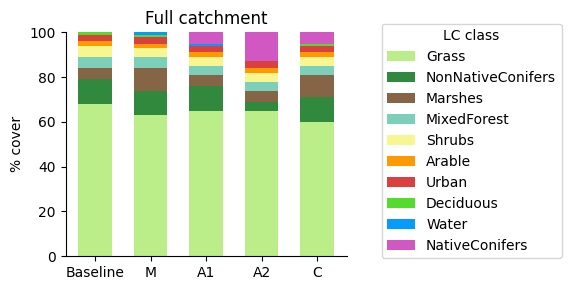

In [4]:
# Plot stacked bar chart for full catchment

area = "Full"
scenarios = ["Baseline", "M", "A1", "A2", "C"]

baseline["scenario"] = "Baseline"
m["scenario"] = "M"
a1["scenario"] = "A1"
a2["scenario"] = "A2"
c["scenario"] = "C"

lc_data = pd.concat([baseline, m, a1, a2, c], ignore_index=True)

lc_long = lc_data.melt(
    id_vars=["LC", "scenario"],
    value_vars=[area],
    var_name="area",
    value_name="percent",
)

lc_classes = lc_long["LC"].unique()
fig, ax = plt.subplots(figsize=(6, 3))

bottom = np.zeros(len(scenarios))
x = np.arange(len(scenarios))

for lc_class in lc_classes:
    class_df = lc_long[lc_long["LC"] == lc_class].set_index("scenario")["percent"]
    values = class_df.reindex(scenarios).fillna(0).values
    colour = LC_colours.get(lc_class, plt.cm.tab20(len(bottom)))
    ax.bar(
        x,
        values,
        0.6,
        bottom=bottom,
        label=lc_class,
        color=colour,
    )
    bottom += values


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title("Full catchment")
ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel("% cover")
ax.set_ylim(0, 100)
#ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(title="LC class", bbox_to_anchor=(1.1, 1.07), loc="upper left")

plt.tight_layout()
plt.show()


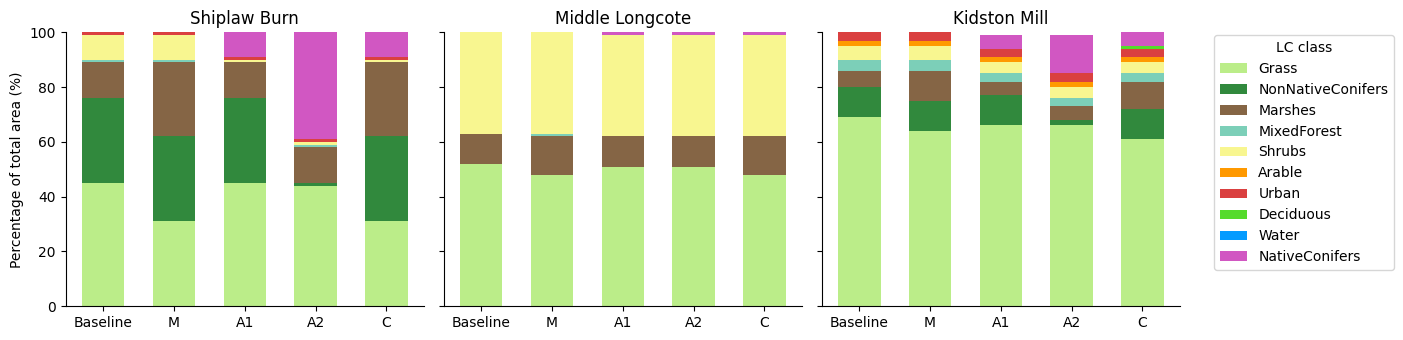

In [5]:
# Panel version for LC scenarios

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Combine scenario dataframes
scenarios = ["Baseline", "M", "A1", "A2", "C"]

baseline["scenario"] = "Baseline"
m["scenario"] = "M"
a1["scenario"] = "A1"
a2["scenario"] = "A2"
c["scenario"] = "C"

lc_data = pd.concat([baseline, m, a1, a2, c], ignore_index=True)

# Areas to plot
areas = {
    "SB": "Shiplaw Burn",
    "ML": "Middle Longcote",
    "KM": "Kidston Mill",
}

lc_classes = lc_data["LC"].unique()
x = np.arange(len(scenarios))

fig, axes = plt.subplots(1, len(areas), figsize=(4 * len(areas), 3.5), sharey=True)

for ax, (area, title) in zip(axes, areas.items()):
    lc_long = lc_data.melt(
        id_vars=["LC", "scenario"],
        value_vars=[area],
        var_name="area",
        value_name="percent",
    )

    bottom = np.zeros(len(scenarios))

    for lc_class in lc_classes:
        class_df = lc_long[lc_long["LC"] == lc_class].set_index("scenario")["percent"]
        values = class_df.reindex(scenarios).fillna(0).values
        colour = LC_colours.get(lc_class, plt.cm.tab20(len(bottom)))
        ax.bar(
            x,
            values,
            0.6,
            bottom=bottom,
            label=lc_class,
            color=colour,
        )
        bottom += values

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios)
    ax.set_ylim(0, 100)

axes[0].set_ylabel("Percentage of total area (%)")

# Shared legend
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="LC class",
    bbox_to_anchor=(1.01, 0.55),
    loc="center left",
)

plt.tight_layout()

plt.savefig("Figure_41.png", dpi=400, bbox_inches="tight")

plt.show()

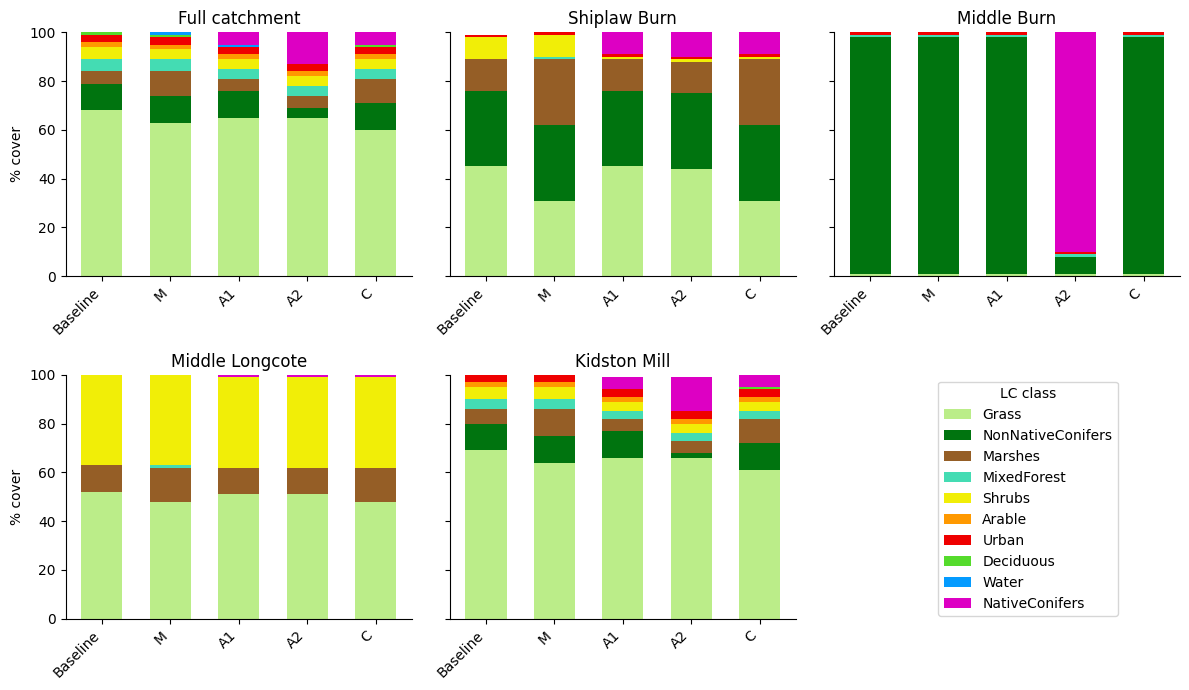

In [72]:

scenarios = ["Baseline", "M", "A1", "A2", "C"]

baseline["scenario"] = "Baseline"
m["scenario"] = "M"
a1["scenario"] = "A1"
a2["scenario"] = "A2"
c["scenario"] = "C"

lc_data = pd.concat([baseline, m, a1, a2, c], ignore_index=True)

areas = {
    "Full": "Full catchment",
    "SB": "Shiplaw Burn",
    "MB": "Middle Burn",
    "ML": "Middle Longcote",
    "KM": "Kidston Mill",
}

lc_classes = lc_data["LC"].unique()
x = np.arange(len(scenarios))

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)
axes_flat = axes.flatten()

for ax, (area, title) in zip(axes_flat, areas.items()):
    lc_long = lc_data.melt(
        id_vars=["LC", "scenario"],
        value_vars=[area],
        var_name="area",
        value_name="percent",
    )

    bottom = np.zeros(len(scenarios))

    for lc_class in lc_classes:
        class_df = lc_long[lc_long["LC"] == lc_class].set_index("scenario")["percent"]
        values = class_df.reindex(scenarios).fillna(0).values
        colour = LC_colours.get(lc_class, plt.cm.tab20(len(bottom)))
        ax.bar(
            x,
            values,
            0.6,
            bottom=bottom,
            label=lc_class,
            color=colour,
        )
        bottom += values

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, rotation=45, ha="right")
    ax.set_ylim(0, 100)

axes[0, 0].set_ylabel("% cover")
axes[1, 0].set_ylabel("% cover")
axes_flat[-1].axis("off")

# Shared legend
handles, labels = axes_flat[len(areas) - 1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="LC class",
    bbox_to_anchor=(0.78, 0.28),
    loc="center left",
)

plt.tight_layout()
plt.show()

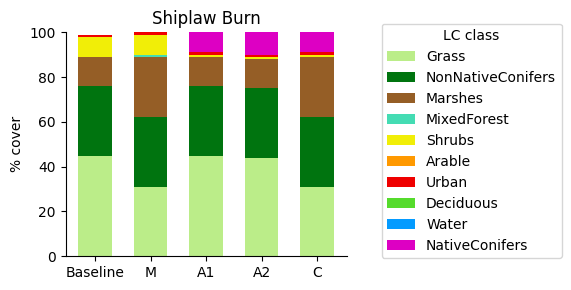

In [68]:
# Shiplaw Burn

area = "SB"
scenarios = ["Baseline", "M", "A1", "A2", "C"]

baseline["scenario"] = "Baseline"
m["scenario"] = "M"
a1["scenario"] = "A1"
a2["scenario"] = "A2"
c["scenario"] = "C"

lc_data = pd.concat([baseline, m, a1, a2, c], ignore_index=True)

lc_long = lc_data.melt(
    id_vars=["LC", "scenario"],
    value_vars=[area],
    var_name="area",
    value_name="percent",
)

lc_classes = lc_long["LC"].unique()
fig, ax = plt.subplots(figsize=(6, 3))

bottom = np.zeros(len(scenarios))
x = np.arange(len(scenarios))

for lc_class in lc_classes:
    class_df = lc_long[lc_long["LC"] == lc_class].set_index("scenario")["percent"]
    values = class_df.reindex(scenarios).fillna(0).values
    colour = LC_colours.get(lc_class, plt.cm.tab20(len(bottom)))
    ax.bar(
        x,
        values,
        0.6,
        bottom=bottom,
        label=lc_class,
        color=colour,
    )
    bottom += values


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title("Shiplaw Burn")
ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel("% cover")
ax.set_ylim(0, 100)
#ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(title="LC class", bbox_to_anchor=(1.1, 1.07), loc="upper left")

plt.tight_layout()
plt.show()


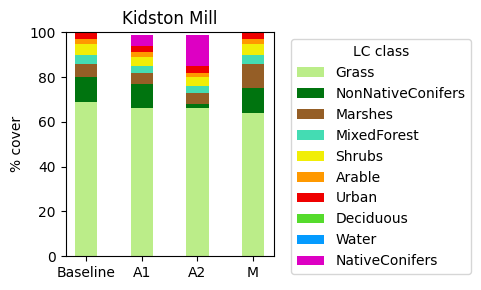

In [44]:
# Shiplaw Burn

area = "SB"
scenarios = ["Baseline", "M", "A1", "A2", "C"]

baseline["scenario"] = "Baseline"
m["scenario"] = "M"
a1["scenario"] = "A1"
a2["scenario"] = "A2"
c["scenario"] = "C"

lc_data = pd.concat([baseline, m, a1, a2, c], ignore_index=True)

lc_long = lc_data.melt(
    id_vars=["LC", "scenario"],
    value_vars=[area],
    var_name="area",
    value_name="percent",
)

lc_classes = lc_long["LC"].unique()
fig, ax = plt.subplots(figsize=(6, 3))

bottom = np.zeros(len(scenarios))
x = np.arange(len(scenarios))

for lc_class in lc_classes:
    class_df = lc_long[lc_long["LC"] == lc_class].set_index("scenario")["percent"]
    values = class_df.reindex(scenarios).fillna(0).values
    colour = LC_colours.get(lc_class, plt.cm.tab20(len(bottom)))
    ax.bar(
        x,
        values,
        0.6,
        bottom=bottom,
        label=lc_class,
        color=colour,
    )
    bottom += values


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title("Shiplaw Burn")
ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel("% cover")
ax.set_ylim(0, 100)
#ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(title="LC class", bbox_to_anchor=(1.1, 1.07), loc="upper left")

plt.tight_layout()
plt.show()
